In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\PFE\dataset\Data\FINAL_CSV\train70_reduced.csv", low_memory=False)
print("Dataset chargé avec succès !")

Dataset chargé avec succès !


In [3]:
df.head()

,tcp.flags,tcp.time_delta,tcp.len,mqtt.conack.flags,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,...,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.ver,mqtt.willmsg,mqtt.willmsg_len,mqtt.willtopic,mqtt.willtopic_len,target
0,0x00000018,0.998867,10,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,legitimate
1,0x00000010,0.000067,1460,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,dos
2,0x00000010,0.000058,1460,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,dos
3,0x00000018,0.000227,10,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,legitimate
4,0x00000018,0.000236,16,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,dos


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231646 entries, 0 to 231645
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   tcp.flags                   231646 non-null  object 
 1   tcp.time_delta              231646 non-null  float64
 2   tcp.len                     231646 non-null  int64  
 3   mqtt.conack.flags           231646 non-null  object 
 4   mqtt.conack.flags.reserved  231646 non-null  float64
 5   mqtt.conack.flags.sp        231646 non-null  float64
 6   mqtt.conack.val             231646 non-null  float64
 7   mqtt.conflag.cleansess      231646 non-null  float64
 8   mqtt.conflag.passwd         231646 non-null  float64
 9   mqtt.conflag.qos            231646 non-null  float64
 10  mqtt.conflag.reserved       231646 non-null  float64
 11  mqtt.conflag.retain         231646 non-null  float64
 12  mqtt.conflag.uname          231646 non-null  float64
 13  mqtt.conflag.w

In [5]:
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes[valeurs_manquantes > 0])
print(f"\nTotal colonnes avec valeurs manquantes : {(valeurs_manquantes > 0).sum()}")

Series([], dtype: int64)

Total colonnes avec valeurs manquantes : 0


In [6]:
print(df["target"].value_counts())
print(f"\nPourcentage :")
print(round(df["target"].value_counts(normalize=True) * 100, 2))

target
legitimate    115824
dos            91156
bruteforce     10150
malformed       7646
slowite         6441
flood            429
Name: count, dtype: int64

Pourcentage :
target
legitimate    50.00
dos           39.35
bruteforce     4.38
malformed      3.30
slowite        2.78
flood          0.19
Name: proportion, dtype: float64


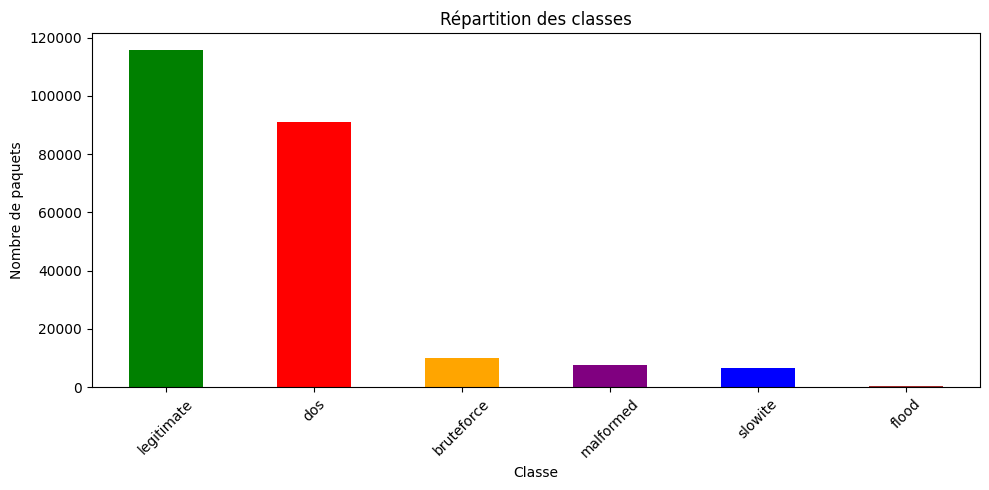

In [7]:
plt.figure(figsize=(10, 5))
df['target'].value_counts().plot(kind='bar', color=['green', 'red', 'orange', 'purple', 'blue', 'brown'])
plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre de paquets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df.describe()

,tcp.time_delta,tcp.len,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,mqtt.conflag.reserved,mqtt.conflag.retain,...,mqtt.proto_len,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.ver,mqtt.willmsg,mqtt.willmsg_len,mqtt.willtopic,mqtt.willtopic_len
count,231646.000000,231646.000000,231646.0,231646.0,231646.000000,231646.000000,231646.000000,231646.0,231646.0,231646.0,...,231646.000000,231646.000000,231646.000000,231646.0,231646.0,231646.000000,231646.0,231646.0,231646.0,231646.0
mean,0.278867,149.962883,0.0,0.0,0.021822,0.009571,0.004330,0.0,0.0,0.0,...,0.038283,0.162990,0.000376,0.0,0.0,0.038283,0.0,0.0,0.0,0.0
std,2.900768,947.521505,0.0,0.0,0.329598,0.097361,0.065659,0.0,0.0,0.0,...,0.389442,0.369357,0.019376,0.0,0.0,0.389442,0.0,0.0,0.0,0.0
min,-0.000002,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
25%,0.000003,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
50%,0.000030,10.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
75%,0.000197,14.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
max,60.000878,32768.000000,0.0,0.0,5.000000,1.000000,1.000000,0.0,0.0,0.0,...,4.000000,1.000000,1.000000,0.0,0.0,4.000000,0.0,0.0,0.0,0.0


In [9]:
doublons = df.duplicated().sum()
print(f"Nombre de doublons : {doublons}")

Nombre de doublons : 142256


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["target_encoded"] =le.fit_transform(df["target"])
print("Classes encodées :")
for i, classe in enumerate(le.classes_):
    print(f" {classe} -> {i}")

Classes encodées :
 bruteforce -> 0
 dos -> 1
 flood -> 2
 legitimate -> 3
 malformed -> 4
 slowite -> 5


In [11]:
X = df.drop(["target", "target_encoded"], axis=1)
y = df["target_encoded"]

print(f" X (feauture) : {X.shape}")
print(f" y (cible) : {y.shape}")

 X (feauture) : (231646, 33)
 y (cible) : (231646,)


In [12]:
from sklearn.preprocessing import LabelEncoder
le2 = LabelEncoder()

colonnes_texte = X.select_dtypes(include='object').columns
print(f"Colonnes texte à encoder : {list(colonnes_texte)}")
for col in colonnes_texte:
    X[col] = le2.fit_transform(X[col].astype(str))

print("Toutes les colonnes texte encodées !")
print(f"Types restants : {X.dtypes.value_counts()}")

Colonnes texte à encoder : ['tcp.flags', 'mqtt.conack.flags', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.msg', 'mqtt.protoname']
Toutes les colonnes texte encodées !
Types restants : float64    26
int64       7
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Normalisation terminée !")
print(f"Shape : {X_scaled.shape}")

Normalisation terminée !
Shape : (231646, 33)


In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}")
print(f"Test : {X_test.shape}")

Train : (185316, 33)
Test : (46330, 33)


In [15]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Entrainement en cours...")
start = time.time()

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

end = time.time()
print(f"Random forest entrainé en {round(end-start, 2)} secondes !")

Entrainement en cours...
Random forest entrainé en 29.98 secondes !


In [16]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy : {round(accuracy_score(y_test, y_pred_rf)*100,2)}%")
print("\n Rapport détaillé :")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy : 94.03%

 Rapport détaillé :
              precision    recall  f1-score   support

  bruteforce       0.74      0.83      0.78      1989
         dos       0.96      0.92      0.94     18241
       flood       0.97      0.46      0.62        81
  legitimate       0.94      0.99      0.97     23253
   malformed       0.83      0.60      0.70      1474
     slowite       1.00      1.00      1.00      1292

    accuracy                           0.94     46330
   macro avg       0.91      0.80      0.83     46330
weighted avg       0.94      0.94      0.94     46330



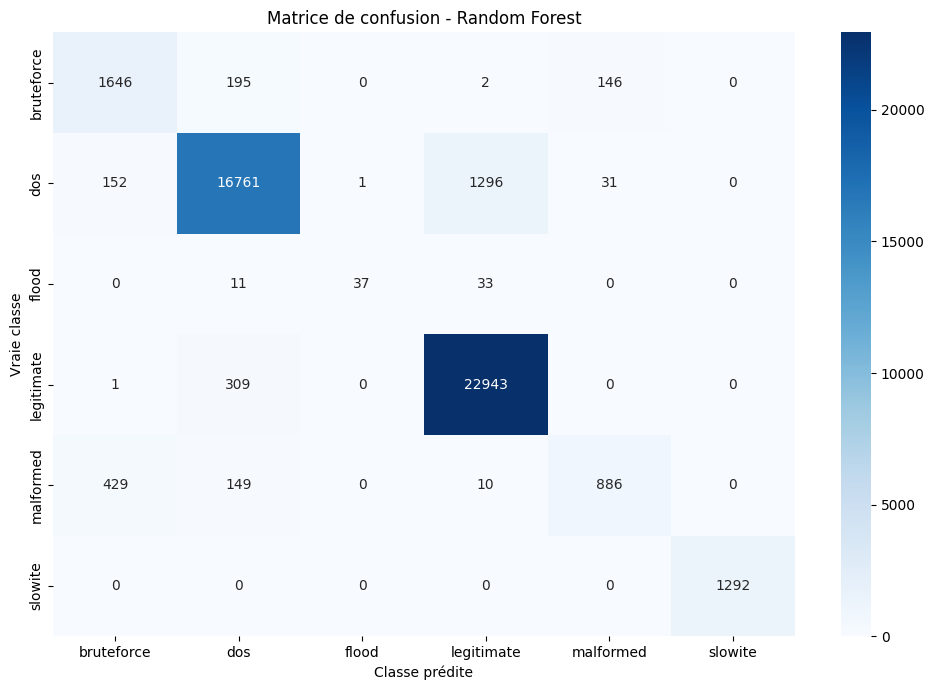

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,7))
sns.heatmap(cm , annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de confusion - Random Forest')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

In [27]:
from xgboost import XGBClassifier
import time

print(" Entraînement en cours...")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train.values)

end = time.time()
print(f"XGBoost entraîné en {round(end-start, 2)} secondes !")
print(f"Modèle prêt : {xgb_model}")

 Entraînement en cours...
XGBoost entraîné en 8.37 secondes !
Modèle prêt : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [28]:
y_pred_xgb = xgb_model.predict(X_test)

print(f"Accuracy : {round(accuracy_score(y_test, y_pred_xgb) * 100, 2)}%")
print("\n Rapport détaillé :")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Accuracy : 94.2%

 Rapport détaillé :
              precision    recall  f1-score   support

  bruteforce       0.74      0.88      0.81      1989
         dos       0.96      0.92      0.94     18241
       flood       1.00      0.42      0.59        81
  legitimate       0.94      0.99      0.96     23253
   malformed       0.93      0.58      0.72      1474
     slowite       1.00      1.00      1.00      1292

    accuracy                           0.94     46330
   macro avg       0.93      0.80      0.84     46330
weighted avg       0.94      0.94      0.94     46330



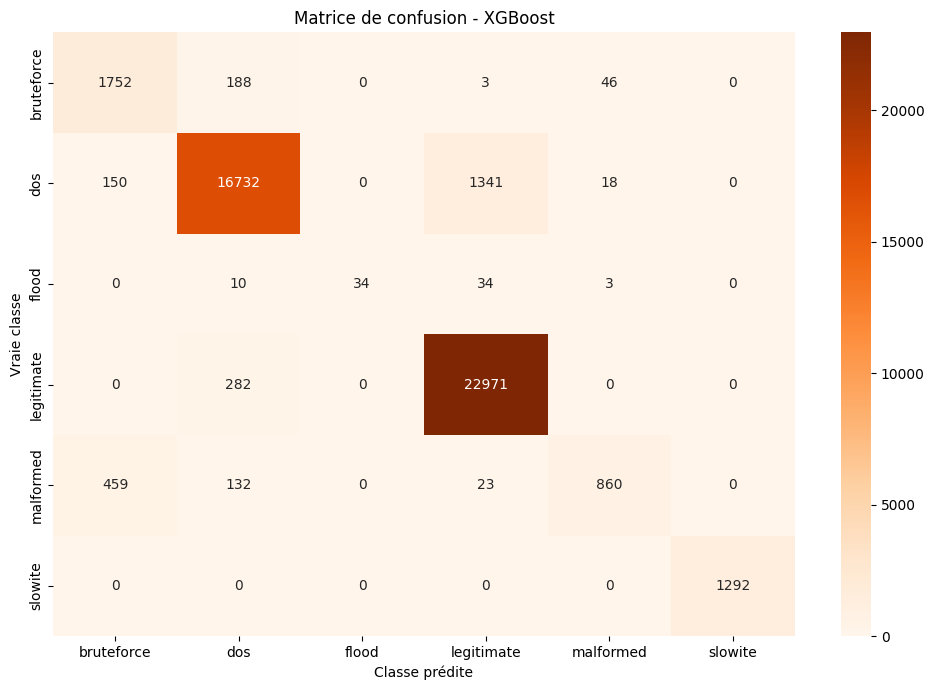

In [29]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matrice de confusion - XGBoost')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.ensemble import IsolationForest
import time

print("Entraînement en cours...")
start = time.time()

iso_model = IsolationForest(n_estimators=100, contamination=0.5, random_state=42)
iso_model.fit(X_train)

end = time.time()
print(f"Isolation Forest entraîné en {round(end-start, 2)} secondes !")

Entraînement en cours...
Isolation Forest entraîné en 3.04 secondes !


In [32]:
y_pred_iso = iso_model.predict(X_test)
# Isolation Forest retourne 1 (normal) et -1 (anomalie)
# On convertit : 1 → legitimate, -1 → anomalie
y_pred_iso_binary = ['legitimate' if x == 1 else 'anomalie' for x in y_pred_iso]
y_test_binary = ['legitimate' if x == 3 else 'anomalie' for x in y_test]

from sklearn.metrics import classification_report, accuracy_score
print(f"Accuracy : {round(accuracy_score(y_test_binary, y_pred_iso_binary) * 100, 2)}%")
print("\n Rapport détaillé :")
print(classification_report(y_test_binary, y_pred_iso_binary))

Accuracy : 74.77%

 Rapport détaillé :
              precision    recall  f1-score   support

    anomalie       0.75      0.74      0.75     23077
  legitimate       0.75      0.75      0.75     23253

    accuracy                           0.75     46330
   macro avg       0.75      0.75      0.75     46330
weighted avg       0.75      0.75      0.75     46330



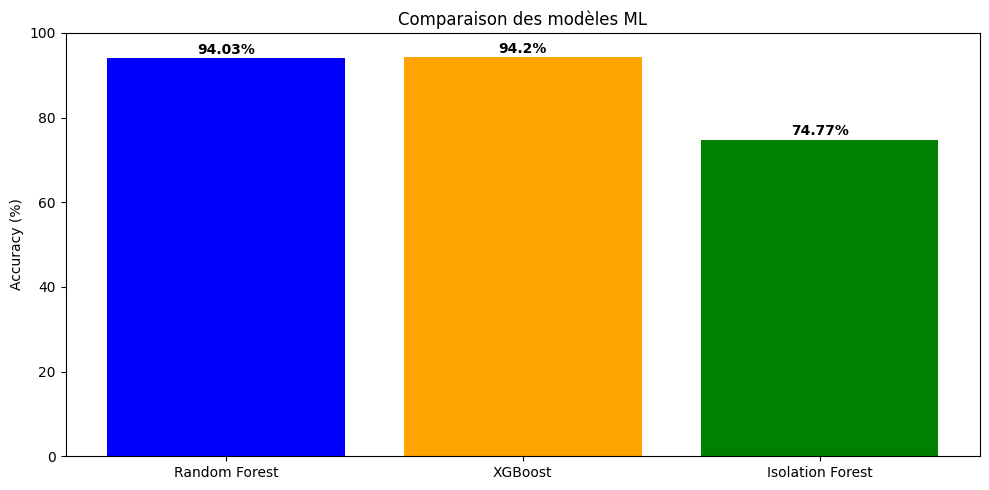

In [33]:
modeles = ['Random Forest', 'XGBoost', 'Isolation Forest']
accuracies = [94.03, 94.2, 74.77]

plt.figure(figsize=(10, 5))
bars = plt.bar(modeles, accuracies, color=['blue', 'orange', 'green'])
plt.title('Comparaison des modèles ML')
plt.ylabel('Accuracy (%)')
plt.ylim([0, 100])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# sauvegarder le modéle XGBoost
import pickle

# Sauvegarder le modèle
with open(r'C:\PFE\models\xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Sauvegarder le scaler
with open(r'C:\PFE\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
# Sauvegarder le label encoder
with open(r'C:\PFE\models\label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Modèle sauvegardé dans C:\\PFE\\models\\")

Modèle sauvegardé dans C:\PFE\models\
